In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")

# Check first few rows
print(df.head())

# Dataset information
print(df.info())

# Convert date columns
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])

# Calculate length of hospital stay
df["Stay Duration"] = (
    df["Discharge Date"] - df["Date of Admission"]
).dt.days

# Total medical cost
df["Total Medical Cost"] = df["Billing Amount"]

print(df.head())

            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Admission Type Discharge Date   Medication  \
0    18856.281306    

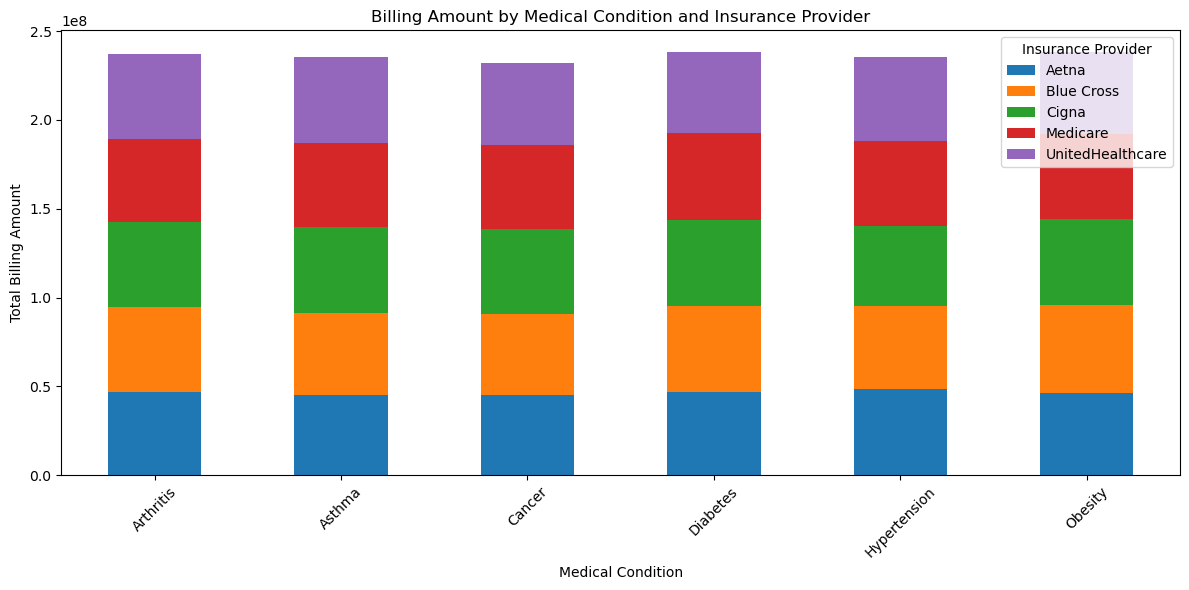

In [4]:
billing_summary = df.pivot_table(
    values="Billing Amount",
    index="Medical Condition",
    columns="Insurance Provider",
    aggfunc="sum"
)

billing_summary.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xlabel("Medical Condition")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.tight_layout()
plt.show()

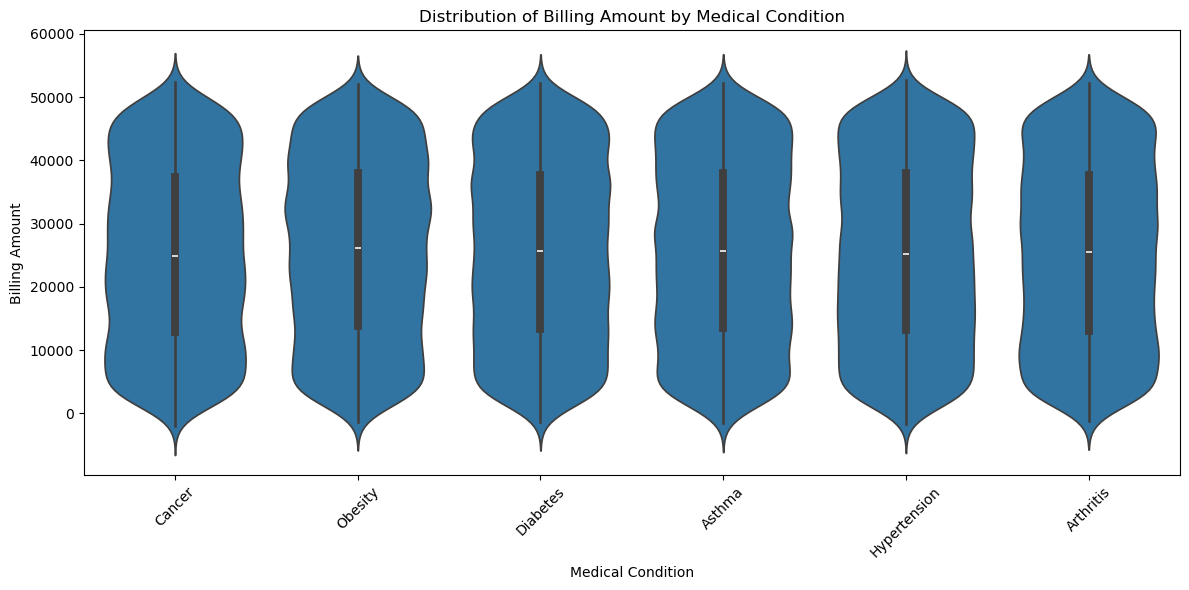

In [6]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

plt.title("Distribution of Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

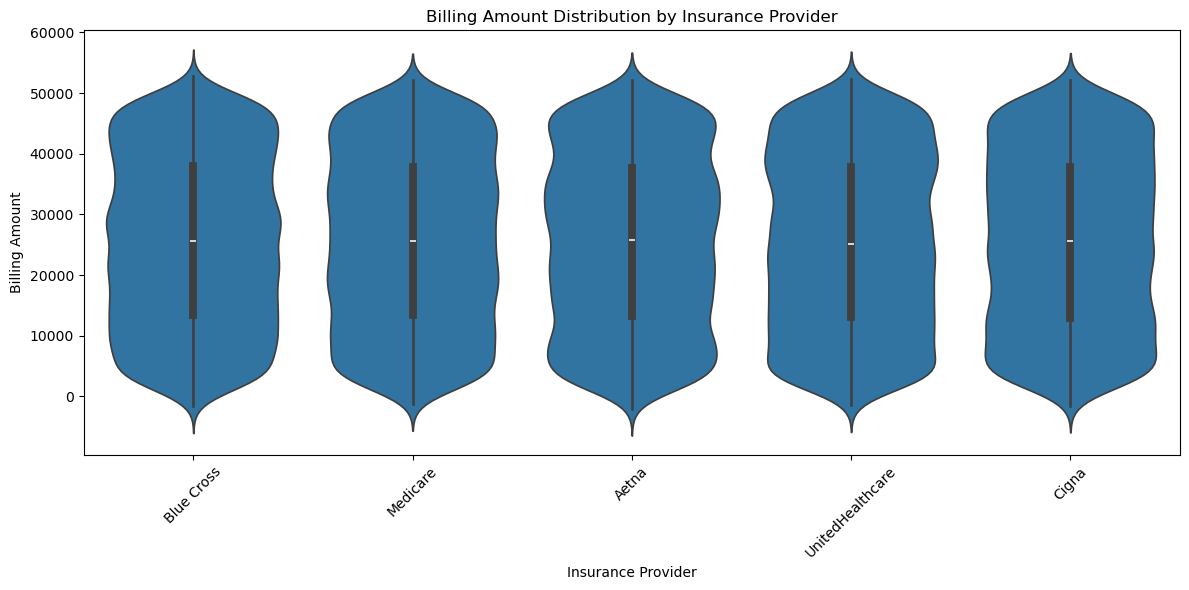

In [8]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Insurance Provider",
    y="Billing Amount"
)

plt.title("Billing Amount Distribution by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

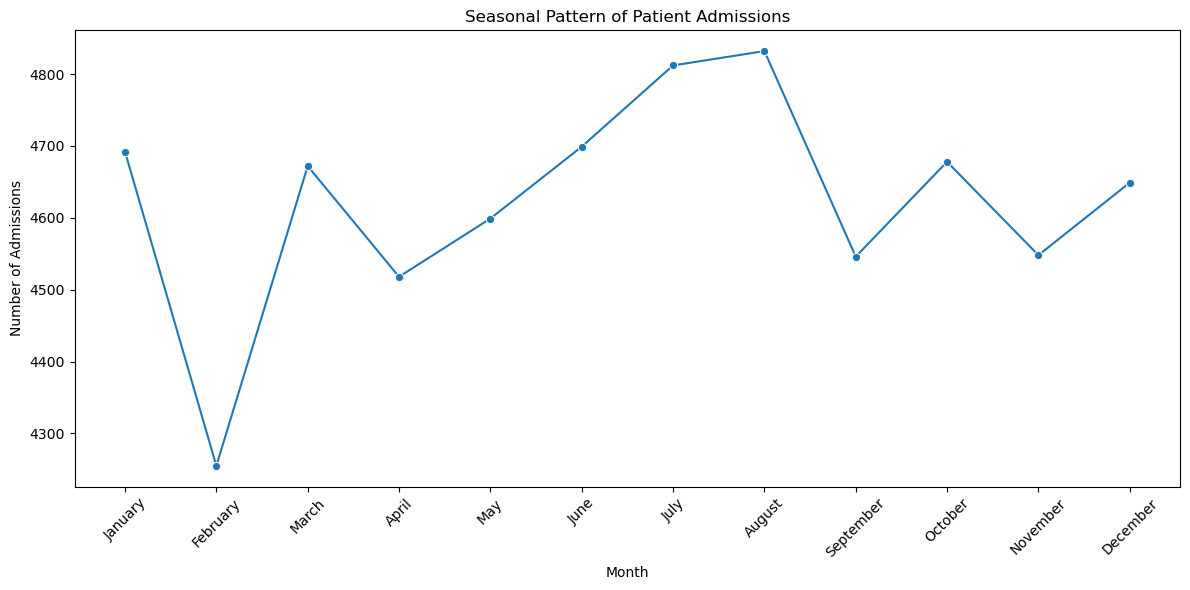

In [10]:
df["Month"] = df["Date of Admission"].dt.month_name()

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

seasonal_admissions = (
    df["Month"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=seasonal_admissions.index,
    y=seasonal_admissions.values,
    marker="o"
)

plt.title("Seasonal Pattern of Patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
correlation_data = df[
    ["Age", "Stay Duration", "Total Medical Cost"]
]

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                         Age  Stay Duration  Total Medical Cost
Age                 1.000000       0.008220           -0.003832
Stay Duration       0.008220       1.000000           -0.005602
Total Medical Cost -0.003832      -0.005602            1.000000


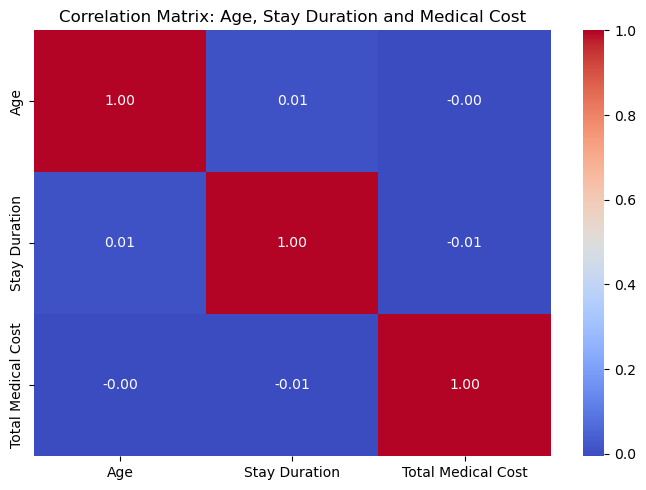

In [14]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix: Age, Stay Duration and Medical Cost"
)

plt.tight_layout()
plt.show()